Max speed at frame  0  is  1.407  m/s
Max speed at frame  2  is  1.37  m/s
Max speed at frame  4  is  1.322  m/s
Max speed at frame  10  is  1.346  m/s


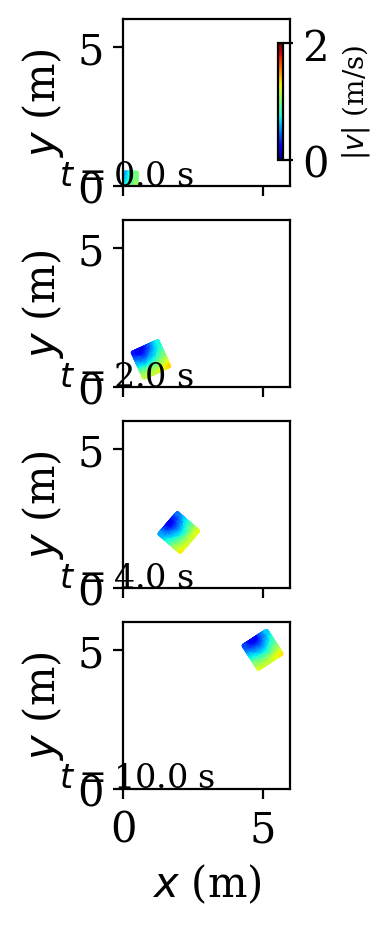

In [7]:
# Copyright (C) 2024 Lars Blatny. Released under GPL-3.0 license.

import numpy as np
from plyfile import PlyData, PlyElement # pip3 install plyfile

###### Plotting settings #######
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({'font.size': 15})
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
dpi = 200
figsize = (5, 5)
###############################

#### Specify file name and frames to plot
# file = "../matter/build/output/collapse/"
file = "../matter/build/output/cube_rotating/"
frames_to_plot = [0,2,4,10]
v_max = 2 # max speed in colorbar

##### Get info from the infofile
info = np.loadtxt(file + "info.txt")
frame_dt  = 1.0 / float(info[1])
dx              = float(info[2])

##### Initialize colormap
cmap = matplotlib.cm.jet
norm = matplotlib.colors.Normalize(vmin=0, vmax=v_max)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])


fig, ax = plt.subplots(len(frames_to_plot), 1, figsize = figsize, dpi = dpi)

for f in range(0, len(frames_to_plot)):
    frame = frames_to_plot[f]
    plydata = PlyData.read(file + 'particles_f' + str(frame) + '.ply')
    x  = plydata.elements[0].data['x']
    y  = plydata.elements[0].data['y']
    vx = plydata.elements[0].data['vx']
    vy = plydata.elements[0].data['vy']
    v = np.sqrt(vx**2 + vy**2)
    Np = len(x);
    print("Max speed at frame ", frame, " is ", round(np.max(v),3), " m/s")

    ax[f].scatter(x,y, c=cmap(norm(v)), s=0.4, marker='.')
    ax[f].text(-2.3, 0.95, r'$t = $' + str(round(frame*frame_dt,2)) + ' s', fontsize=12, verticalalignment='top')

    ax[f].set_ylabel(r'$y$ (m)')
    # ax[f].set(xlim=(-2.5, 2.5), ylim=(0, 1.05))
    # ax[f].set_xticks([-2, -1, 0, 1, 2])
    # ax[f].set_yticks([0, 0.5, 1])
    ax[f].set(xlim=(0, 6), ylim=(0, 6))
    # ax[f].set_xticks([-2, -1, 0, 1, 2])
    # ax[f].set_yticks([0, 0.5, 1])
    ax[f].set_aspect("equal")

for f in range(0, len(frames_to_plot)-1):
    ax[f].tick_params(labelbottom=False)


cbaxes = inset_axes(ax[0], width="3%", height="70%", loc='upper left', bbox_to_anchor=(0.8,-0.02,1,1), bbox_transform=ax[0].transAxes)
cbar = plt.colorbar(sm, cax=cbaxes, orientation='vertical', ticks=[0,v_max])
cbar.set_label(r'$|v|$ (m/s)',rotation=90, fontsize=10)

ax[len(frames_to_plot)-1].set_xlabel(r'$x$ (m)')
plt.savefig(file + "my_plot.png", bbox_inches = 'tight')